In [3]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [4]:
#configuration
DATA_ROOT = "/workspace/ML Main Large/Processed data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 15
LR = 1e-4
MODEL_SAVE = "unet_lite_best.pth"
SEED = 42

PRED_SAVE_DIR = os.path.join(DATA_ROOT, "Predictions_Unet_Lite")
os.makedirs(PRED_SAVE_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
#dataset class
class RoadDataset(Dataset):
    def __init__(self, root, split="train", transforms=None, has_masks=True):
        self.img_dir = os.path.join(root, split, "images")
        self.mask_dir = os.path.join(root, split, "masks")
        self.transforms = transforms
        self.has_masks = has_masks

        self.img_paths = sorted([os.path.join(self.img_dir, f)
                                 for f in os.listdir(self.img_dir)])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # train split has masks, test does not
        if self.has_masks:
            base = os.path.basename(img_path).split("_sat")[0]
            mask_path = os.path.join(self.mask_dir, f"{base}_mask.png")
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype("float32")
        else:
            mask = np.zeros((img.shape[0], img.shape[1]), dtype="float32")

        if self.transforms:
            aug = self.transforms(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"] if isinstance(aug["mask"], np.ndarray) else aug["mask"].numpy()

        img = img.float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return img, mask

In [6]:
#Augmentations
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

In [7]:
#Unet Lite Model
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetLite(nn.Module):
    def __init__(self):
        super().__init__()
        f = 32

        self.enc1 = DoubleConv(3, f)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(f, f*2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(f*2, f*4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(f*4, f*8)

        self.up3 = nn.ConvTranspose2d(f*8, f*4, 2, 2)
        self.dec3 = DoubleConv(f*8, f*4)

        self.up2 = nn.ConvTranspose2d(f*4, f*2, 2, 2)
        self.dec2 = DoubleConv(f*4, f*2)

        self.up1 = nn.ConvTranspose2d(f*2, f, 2, 2)
        self.dec1 = DoubleConv(f*2, f)

        self.final = nn.Conv2d(f, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)

In [19]:
#loss and metrics
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, eps=1e-6):
    p = torch.sigmoid(pred)
    inter = (p * target).sum()
    denom = p.sum() + target.sum()
    return 1 - ((2 * inter + eps) / (denom + eps))

def total_loss(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

def iou(pred, target, thr=0.5):
    p = (torch.sigmoid(pred) > thr).float()
    inter = (p * target).sum()
    union = p.sum() + target.sum() - inter
    return (inter / union).item() if union > 0 else 0

In [24]:
# training function
def train_model():

    # LOAD FULL TRAIN SET (with masks)
    full_train_ds = RoadDataset(DATA_ROOT, "train", train_transform, has_masks=True)
    
    # CREATE TRAIN / VALIDATION SPLIT
    val_ratio = 0.10
    val_size = int(len(full_train_ds) * val_ratio)
    train_size = len(full_train_ds) - val_size
    
    train_ds, val_ds = torch.utils.data.random_split(
        full_train_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    # TEST SET (NO MASKS)
    test_ds = RoadDataset(DATA_ROOT, "test", test_transform, has_masks=False)


    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False)


    model = UNetLite().to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR)

    train_losses = []
    train_ious = []

    # Training Loop
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0
        epoch_iou = 0

        print(f"\nEpoch {epoch}/{EPOCHS}")

        for imgs, masks in tqdm(train_loader):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            preds = model(imgs)
            loss = total_loss(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_iou += iou(preds, masks)

        avg_loss = epoch_loss / len(train_loader)
        avg_iou = epoch_iou / len(train_loader)

        train_losses.append(avg_loss)
        train_ious.append(avg_iou)

        print(f"Training Loss: {avg_loss:.4f}")
        print(f"Training IoU:  {avg_iou:.4f}")

        # VALIDATION LOOP
        model.eval()
        val_loss = 0
        val_iou = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                preds = model(imgs)

                loss = total_loss(preds, masks)
                val_loss += loss.item()
                val_iou += iou(preds, masks)

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)

        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Validation IoU:  {val_iou:.4f}")

        torch.save(model.state_dict(), MODEL_SAVE)

    # Show Loss Curve
    plt.plot(train_losses, marker="o")
    plt.title("Training Loss Across Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

    # Show IoU Curve
    plt.plot(train_ious, marker="o", color="green")
    plt.title("Training IoU Across Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.grid()
    plt.show()
    # SHOW PREDICTIONS ON TEST DATASET (NO SAVING)
    print("\nShowing predictions for a few test images...")

    model.eval()
    num_samples = 4  # number of test images to visualize

    with torch.no_grad():
        plt.figure(figsize=(12, 4 * num_samples))

        for i in range(num_samples):
            img, _ = test_ds[i]
            inp = img.unsqueeze(0).to(DEVICE)

            with torch.amp.autocast(device_type="cuda" if DEVICE == "cuda" else "cpu"):
                pred = model(inp)

            pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze().numpy()
            img_np = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)

            # Plot Image
            plt.subplot(num_samples, 3, i*3 + 1)
            plt.imshow(img_np)
            plt.title("Test Image")
            plt.axis("off")

            # Plot Pred Mask
            plt.subplot(num_samples, 3, i*3 + 2)
            plt.imshow(pred_mask, cmap="gray")
            plt.title("Predicted Mask")
            plt.axis("off")

            # Plot Overlay
            plt.subplot(num_samples, 3, i*3 + 3)
            plt.imshow(img_np)
            plt.imshow(pred_mask, cmap="Reds", alpha=0.4)
            plt.title("Overlay")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    print("\nVisualization complete.")
    return model


Epoch 1/15



00%|██████████| 3672/3672 [00:54<00:00, 67.30it/s]

Training Loss: 0.8243
Training IoU:  0.3712

Epoch 2/15



00%|██████████| 3672/3672 [00:54<00:00, 67.42it/s]

Training Loss: 0.4794
Training IoU:  0.4542

Epoch 3/15


...

Training Loss: 0.3807
Training IoU:  0.5321

Epoch 14/15



00%|██████████| 3672/3672 [00:54<00:00, 67.49it/s]

Training Loss: 0.3781
Training IoU:  0.5345

Epoch 15/15



00%|██████████| 3672/3672 [00:54<00:00, 67.42it/s]

Training Loss: 0.3754
Training IoU:  0.5371


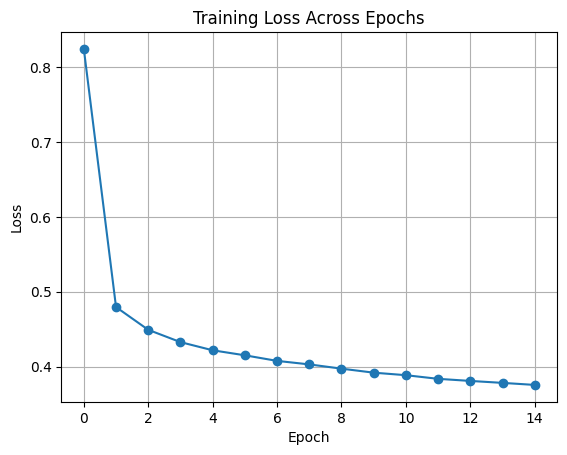

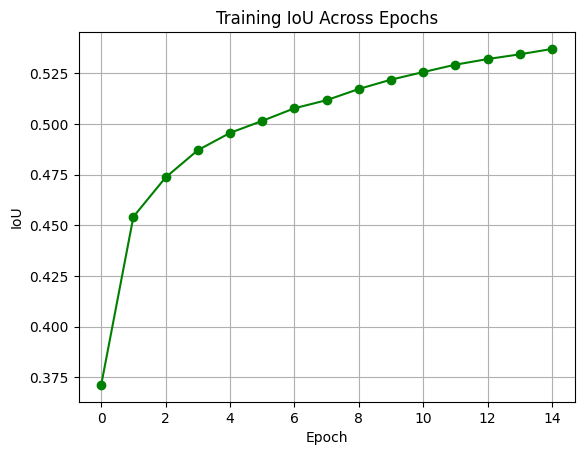


Showing predictions for a few test images...


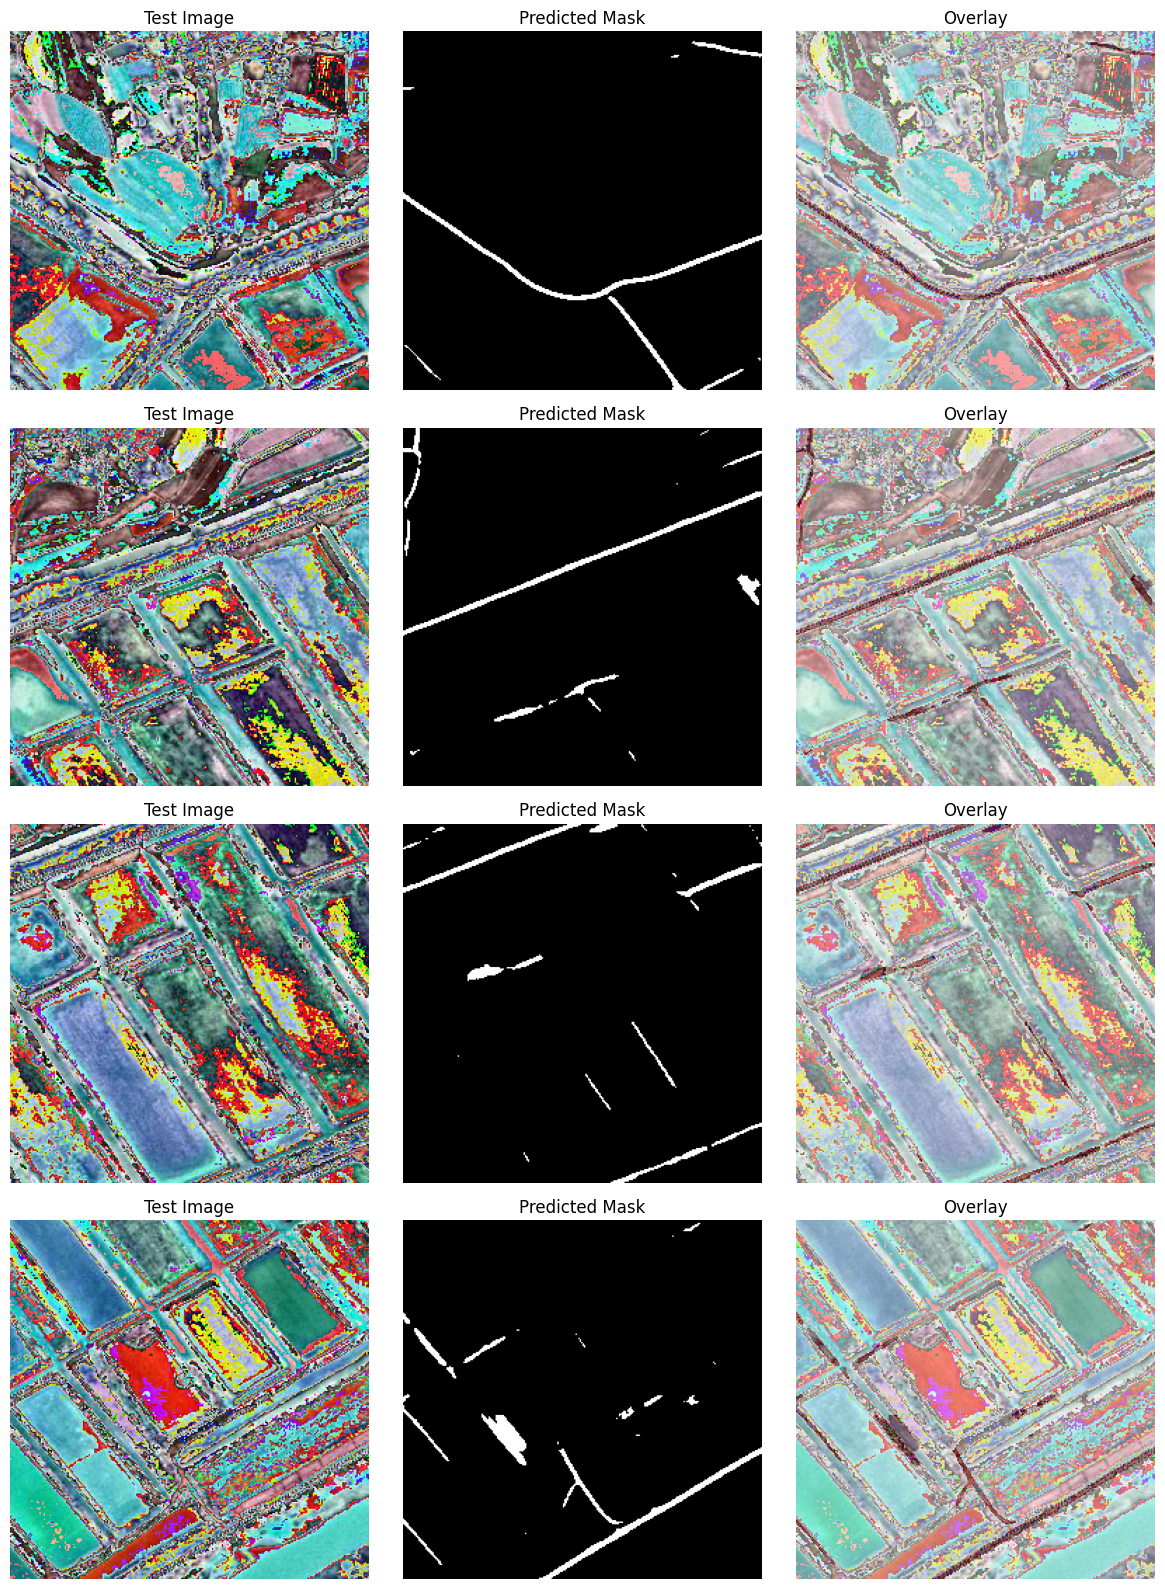


Visualization complete.


UNetLite(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [25]:
train_model()

In [27]:
#evaluating saved model to get validation IoU
def evaluate_saved_model():
    full_train_ds = RoadDataset(DATA_ROOT, "train", test_transform, has_masks=True)

    val_ratio = 0.10
    val_size = int(len(full_train_ds) * val_ratio)
    train_size = len(full_train_ds) - val_size

    _, val_ds = torch.utils.data.random_split(
        full_train_ds,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

    model = UNetLite().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
    model.eval()

    val_loss = 0
    val_iou = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)

            val_loss += total_loss(preds, masks).item()
            val_iou  += iou(preds, masks)

    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)

    print("Validation Loss:", val_loss)
    print("Validation IoU:", val_iou)
evaluate_saved_model()

Validation Loss: 0.3734491068149133
Validation IoU: 0.5373982196567169
